# Preparación y análisis del corpus

Este notebook cubre las fases previas al entrenamiento del modelo de clasificación de intención:

1. **Carga y filtrado** del dataset CLINC150 al subdominio de cocina (8 intenciones).
2. **Análisis exploratorio (EDA)**: distribución de clases, longitudes, vocabulario y ejemplos representativos.
3. **Construcción del corpus bilingüe**: fusión de particiones y traducción automática al español.
4. **Pipeline de preprocesamiento y normalización**: expansión de contracciones, lematización, corrección ortográfica, sinónimos y stopwords.
5. **Análisis del preprocesamiento**: comparativas antes/después y estadísticas del corpus resultante.
6. **Exportación** de los datos limpios para usar en `PoC_PLN.ipynb`.

**Salidas de este notebook** (guardadas en la carpeta `data/`):
- `data/data_train.csv`, `data/data_test.csv` - datos brutos bilingües
- `data/clean_data_train_en.csv`, `data/clean_data_test_en.csv` - datos preprocesados en inglés
- `data/clean_data_train_es.csv`, `data/clean_data_test_es.csv` - datos preprocesados en español

## 1. Carga y filtrado de CLINC150

In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

print('Cargando CLINC150 (configuración plus)...')
dataset = load_dataset('clinc_oos', 'plus')
print(dataset)

/Users/antoniommff/Developer/pln-faq-assistant/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cargando CLINC150 (configuración plus)...


Generating test split: 100%|██████████| 5500/5500 [00:00<00:00, 1225232.21 examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'intent'],
        num_rows: 15250
    })
    validation: Dataset({
        features: ['text', 'intent'],
        num_rows: 3100
    })
    test: Dataset({
        features: ['text', 'intent'],
        num_rows: 5500
    })
})


CLINC150 viene partido en tres conjuntos. Dado el volumen reducido tras el filtrado al dominio de cocina (≈150 ejemplos por clase en total), fusionamos `train` y `validation` como conjunto de entrenamiento y reservamos `test` para la evaluación final.

In [ ]:
nombres_intenciones = dataset['train'].features['intent'].names

# Las 8 intenciones del dominio de cocina disponibles en CLINC150
INTENCIONES_COCINA = [
    'meal_suggestion',
    'recipe',
    'ingredients_list',
    'ingredient_substitution',
    'nutrition_info',
    'calories',
    'cook_time',
    'food_last',
]

# Convertir a DataFrame y añadir nombre de intención
df_train = dataset['train'].to_pandas()
df_val   = dataset['validation'].to_pandas()
df_test  = dataset['test'].to_pandas()

for df in [df_train, df_val, df_test]:
    df['intent_name'] = df['intent'].apply(lambda x: nombres_intenciones[x])

# Filtrar al dominio de cocina
cocina_train = df_train[df_train['intent_name'].isin(INTENCIONES_COCINA)].copy()
cocina_val   = df_val[df_val['intent_name'].isin(INTENCIONES_COCINA)].copy()
cocina_test  = df_test[df_test['intent_name'].isin(INTENCIONES_COCINA)].copy()

print(f'Train (original): {len(df_train):,} -> cocina: {len(cocina_train)}')
print(f'Val   (original): {len(df_val):,} -> cocina: {len(cocina_val)}')
print(f'Test  (original): {len(df_test):,} -> cocina: {len(cocina_test)}')

Train (original): 15,250 → cocina: 800
Val   (original): 3,100 → cocina: 160
Test  (original): 5,500 → cocina: 240


## 2. Análisis exploratorio del corpus (EDA)

### 2.1 Distribución de clases

In [3]:
def comprobar_balanceo(dict_datasets):
    conteos = []
    for nombre, df in dict_datasets.items():
        c = df['intent_name'].value_counts().to_frame()
        c.columns = [nombre]
        conteos.append(c)
    resumen = pd.concat(conteos, axis=1).fillna(0).astype(int)
    resumen['Total'] = resumen.sum(axis=1)
    return resumen.sort_values('Total', ascending=False)

df_balanceo = comprobar_balanceo({'Train': cocina_train, 'Val': cocina_val, 'Test': cocina_test})
print(df_balanceo)

                         Train  Val  Test  Total
intent_name                                     
nutrition_info             100   20    30    150
food_last                  100   20    30    150
cook_time                  100   20    30    150
ingredient_substitution    100   20    30    150
calories                   100   20    30    150
ingredients_list           100   20    30    150
meal_suggestion            100   20    30    150
recipe                     100   20    30    150


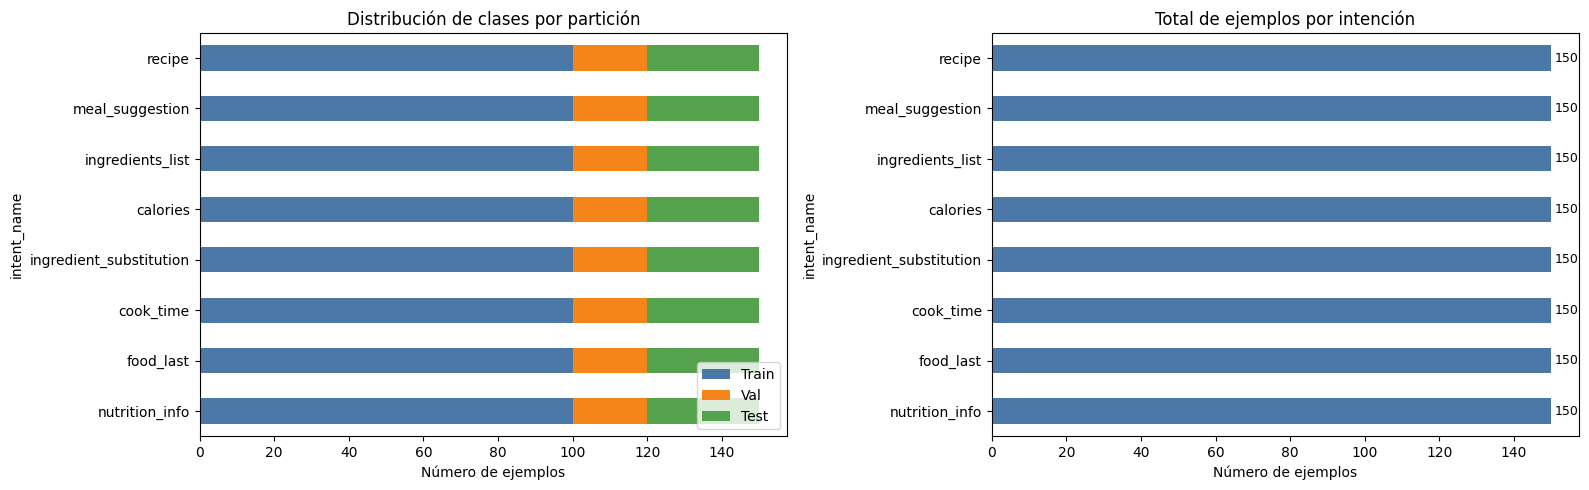


Clases: 8 intenciones perfectamente balanceadas.


In [ ]:
# Visualización del balanceo
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico de barras apiladas por partición
df_plot = df_balanceo.drop(columns='Total')
df_plot.plot(kind='barh', stacked=True, ax=axes[0],
             color=['#4C78A8', '#F58518', '#54A24B'])
axes[0].set_title('Distribución de clases por partición')
axes[0].set_xlabel('Número de ejemplos')
axes[0].legend(loc='lower right')

# Total por clase
df_balanceo['Total'].sort_values().plot(kind='barh', ax=axes[1], color='#4C78A8')
axes[1].set_title('Total de ejemplos por intención')
axes[1].set_xlabel('Número de ejemplos')
for i, v in enumerate(df_balanceo['Total'].sort_values()):
    axes[1].text(v + 1, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()
print(f'\nClases: {len(df_balanceo)} intenciones perfectamente balanceadas.')

Las 8 intenciones presentan un **balance perfecto**: 100 ejemplos en train, 20 en val y 30 en test por clase. Esto permite usar *accuracy* como métrica global sin ajustes de ponderación.

### 2.2 Análisis de longitud de textos

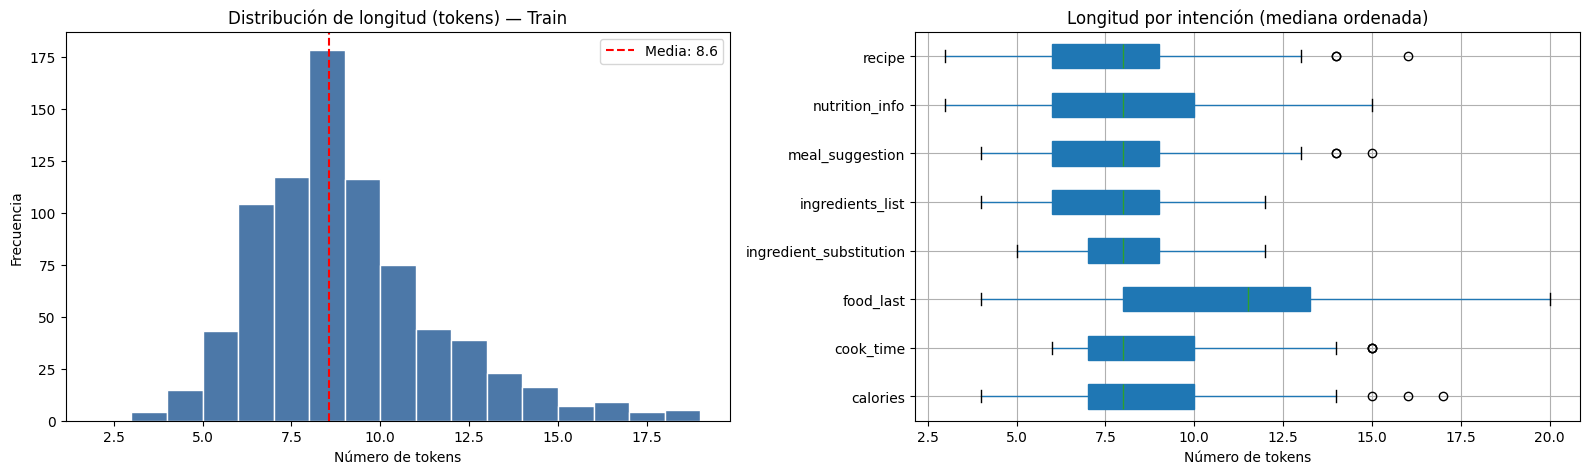

Estadísticas de longitud (tokens):
count    800.00
mean       8.56
std        2.62
min        3.00
25%        7.00
50%        8.00
75%       10.00
max       20.00

Longitud por intención (mediana):
intent_name
calories                    8.0
cook_time                   8.0
ingredient_substitution     8.0
ingredients_list            8.0
meal_suggestion             8.0
nutrition_info              8.0
recipe                      8.0
food_last                  11.5


In [ ]:
# Calculamos longitudes en tokens (palabras) para el conjunto de train
cocina_train['n_tokens'] = cocina_train['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma global
axes[0].hist(cocina_train['n_tokens'], bins=range(2, 20), edgecolor='white', color='#4C78A8')
axes[0].set_title('Distribución de longitud (tokens) - Train')
axes[0].set_xlabel('Número de tokens')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(cocina_train['n_tokens'].mean(), color='red', linestyle='--',
                label=f"Media: {cocina_train['n_tokens'].mean():.1f}")
axes[0].legend()

# Box plot por intención
order = cocina_train.groupby('intent_name')['n_tokens'].median().sort_values().index
cocina_train.boxplot(column='n_tokens', by='intent_name', ax=axes[1],
                      vert=False, patch_artist=True)
axes[1].set_title('Longitud por intención (mediana ordenada)')
axes[1].set_xlabel('Número de tokens')
axes[1].set_ylabel('')
plt.suptitle('')

plt.tight_layout()
plt.show()

print('Estadísticas de longitud (tokens):')
print(cocina_train['n_tokens'].describe().round(2).to_string())
print(f"\nLongitud por intención (mediana):")
print(cocina_train.groupby('intent_name')['n_tokens'].median().sort_values().to_string())

### 2.3 Ejemplos representativos por clase

In [ ]:
N = 3  # Número de ejemplos por intención

for intencion in INTENCIONES_COCINA:
    print(f'\n{'─'*60}')
    print(f'Intención: {intencion}')
    print('─'*60)
    muestra = cocina_train[cocina_train['intent_name'] == intencion].head(N)
    for i, (_, fila) in enumerate(muestra.iterrows(), 1):
        print(f'  {i}. {fila["text"]}')


────────────────────────────────────────────────────────────
Intención: meal_suggestion
────────────────────────────────────────────────────────────
  1. can you give me a french dinner suggestion
  2. suggest a meal from laos to me, please
  3. can you give me a vietnamese meal suggestion
  4. suggest a meal from burma to me
  5. can you give me a vietnamese dinner suggestion

────────────────────────────────────────────────────────────
Intención: recipe
────────────────────────────────────────────────────────────
  1. whats the best way to roast a chicken
  2. how do i make pie crust
  3. find a recipe for german chocolate cake
  4. how do i fry pork chops
  5. how do i cook boiled eggs

────────────────────────────────────────────────────────────
Intención: ingredients_list
────────────────────────────────────────────────────────────
  1. what do you put in chicken noodle casserole
  2. what goes into chicken noodle casserole
  3. what do i need to make chicken noodle casserole
  4

## 3. Construcción del corpus bilingüe

### 3.1 Fusión de particiones y reetiquetado

In [8]:
# Reetiquetado compacto (1–8) para las 8 intenciones de cocina
MAPEO_INTENCIONES = {
    'meal_suggestion': 1,
    'recipe': 2,
    'ingredients_list': 3,
    'ingredient_substitution': 4,
    'nutrition_info': 5,
    'calories': 6,
    'cook_time': 7,
    'food_last': 8,
}

# Fusión train + val; test se reserva para evaluación final
dataset_train = pd.concat([cocina_train, cocina_val]).reset_index(drop=True)
dataset_train['intent'] = dataset_train['intent_name'].map(MAPEO_INTENCIONES)

dataset_test = cocina_test.reset_index(drop=True)
dataset_test['intent'] = dataset_test['intent_name'].map(MAPEO_INTENCIONES)

print(f'Train (train+val): {len(dataset_train)} ejemplos')
print(f'Test:              {len(dataset_test)} ejemplos')
print(f'\nDistribución de clases en train:')
print(dataset_train['intent_name'].value_counts().to_string())

Train (train+val): 960 ejemplos
Test:              240 ejemplos

Distribución de clases en train:
intent_name
nutrition_info             120
food_last                  120
cook_time                  120
ingredient_substitution    120
calories                   120
ingredients_list           120
meal_suggestion            120
recipe                     120


### 3.2 Traducción automática al español

CLINC150 es un corpus nativo en inglés. Para soportar consultas en español, generamos una copia traducida de cada ejemplo usando `deep_translator` (Google Translate). Se asume el riesgo de traducciones demasiado literales, inherente a cualquier corpus generado por traducción automática.

In [9]:
!pip install deep_translator -q

/Users/antoniommff/.zshenv:.:1: no such file or directory: /Users/antoniommff/.cargo/env


In [10]:
from deep_translator import GoogleTranslator

translator = GoogleTranslator(source='en', target='es')

def aumentar_idioma(df):
    df = df.copy()
    df['language'] = 'en'
    df_es = df.copy()
    df_es['language'] = 'es'
    print(f'Traduciendo {len(df)} filas...')
    df_es['text'] = df_es['text'].apply(lambda x: translator.translate(str(x)))
    df_expandido = pd.concat([df, df_es], ignore_index=True)
    print('Listo.')
    return df_expandido

train_final = aumentar_idioma(dataset_train)
test_final  = aumentar_idioma(dataset_test)

Traduciendo 960 filas...
Listo.
Traduciendo 240 filas...
Listo.


In [11]:
# Verificación: comparar ejemplos EN/ES
print('Ejemplos EN -> ES (test, primeras 10 filas por idioma)\n')
muestra_en = test_final[test_final['language'] == 'en'].head(5)
muestra_es = test_final[test_final['language'] == 'es'].head(5)

for (_, row_en), (_, row_es) in zip(muestra_en.iterrows(), muestra_es.iterrows()):
    print(f'[EN] {row_en["text"]}')
    print(f'[ES] {row_es["text"]}')
    print()

Ejemplos EN -> ES (test, primeras 10 filas por idioma)

[EN] tell me nutritional info for brocoli
[ES] dime información nutricional del brócoli

[EN] tell me nutritional info for lettuce
[ES] dime información nutricional de la lechuga

[EN] tell me nutritional info for fish
[ES] dime información nutricional del pescado

[EN] tell me nutritional info for burger
[ES] dime información nutricional de la hamburguesa

[EN] tell me nutritional info for beans
[ES] dime información nutricional de los frijoles



In [ ]:
import os
os.makedirs('data', exist_ok=True)

train_final.to_csv('data/data_train.csv', index=False)
test_final.to_csv('data/data_test.csv', index=False)
print('Guardado: data/data_train.csv y data/data_test.csv')

## 4. Pipeline de preprocesamiento y normalización

### 4.1 Descripción del flujo

El pipeline aplica los siguientes pasos **en orden**:

| Paso | Descripción |
|------|-------------|
| 1. Expansión de contracciones/slang | `I'm` -> `I am`; `kiero` -> `quiero` |
| 2. Tokenización y eliminación de puntuación | spaCy: extrae tokens limpiando signos de puntuación |
| 3. Lematización con excepciones | `manzanas` -> `manzana`; `gluten` se protege de lemas incorrectos |
| 4. Corrección ortográfica (solo producción) | pyspellchecker con *whitelist* de términos culinarios |
| 5. Normalización | Eliminar tildes y convertir a minúsculas |
| 6. Filtrado de stopwords | Se retienen negaciones y términos clave del dominio |
| 7. Sustitución de sinónimos/regionalismos | `papa` -> `patata`; `palta` -> `aguacate` |

In [13]:
!pip install spacy pyspellchecker lingua-language-detector unidecode contractions -q
!python -m spacy download es_core_news_sm -q
!python -m spacy download en_core_web_sm -q

/Users/antoniommff/.zshenv:.:1: no such file or directory: /Users/antoniommff/.cargo/env
/Users/antoniommff/.zshenv:.:1: no such file or directory: /Users/antoniommff/.cargo/env
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
/Users/antoniommff/.zshenv:.:1: no such file or directory: /Users/antoniommff/.cargo/env
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [ ]:
import pandas as pd

data_train = pd.read_csv('data/data_train.csv')
data_test  = pd.read_csv('data/data_test.csv')

data_train_es = data_train[data_train['language'] == 'es'].copy()
data_test_es  = data_test[data_test['language'] == 'es'].copy()
data_train_en = data_train[data_train['language'] == 'en'].copy()
data_test_en  = data_test[data_test['language'] == 'en'].copy()

print(f'Train EN: {len(data_train_en)} | Test EN: {len(data_test_en)}')
print(f'Train ES: {len(data_train_es)} | Test ES: {len(data_test_es)}')

In [ ]:
import re
import pandas as pd
import unidecode
import contractions
import spacy
from spellchecker import SpellChecker
from lingua import Language, LanguageDetectorBuilder

# ── 1. Carga de modelos ──────────────────────────────────────────────
print('Cargando modelos...')
nlp_es = spacy.load('es_core_news_sm')
nlp_en = spacy.load('en_core_web_sm')
detector = LanguageDetectorBuilder.from_languages(Language.SPANISH, Language.ENGLISH).build()

spell_es = SpellChecker(language='es')
spell_en = SpellChecker(language='en')
spell_es.word_frequency.load_words(
    ['aove', 'thermomix', 'airfryer', 'umami', 'keto', 'dente',
     'pizza', 'sushi', 'confit', 'wok', 'bowl', 'tupper', 'smoothie', 'pancake', 'crepe']
)
spell_en.word_frequency.load_words(
    ['bbq', 'thermomix', 'airfryer', 'umami', 'keto', 'dente', 'ramen']
)

# ── 2. Diccionarios ──────────────────────────────────────────────────
KEEP_ES = {
    'no', 'sin', 'excepto', 'nunca', 'jamas',
    'cuando', 'como', 'cuanto', 'antes', 'despues',
    'hacer', 'estar', 'ser', 'buen', 'mal',
    'gluten', 'lactosa', 'proteina', 'vegano', 'vegana', 'keto', 'umami'
}
KEEP_EN = {
    'no', 'not', 'without', 'never', 'free',
    'when', 'how', 'before', 'after',
    'make', 'good', 'bad',
    'gluten', 'lactose', 'vegan', 'keto', 'umami', 'bbq'
}

STOPWORDS_ES = {unidecode.unidecode(w).lower() for w in nlp_es.Defaults.stop_words} - KEEP_ES
STOPWORDS_EN = {unidecode.unidecode(w).lower() for w in nlp_en.Defaults.stop_words} - KEEP_EN

SLANG_ES = {
    'aser': 'hacer', 'kiero': 'quiero', 'q': 'que', 'xq': 'porque',
    'komo': 'como', 'weno': 'bueno', 'k': 'que', 'x': 'por'
}

EXCEPCIONES_LEMAS_ES = {
    'gluten': 'gluten', 'proteina': 'proteina', 'lactosa': 'lactosa',
    'vegano': 'vegano', 'vegana': 'vegano', 'bizcocho': 'bizcocho',
    'aove': 'aove', 'pizza': 'pizza'
}
EXCEPCIONES_LEMAS_EN = {
    'gluten': 'gluten', 'ramen': 'ramen', 'vegan': 'vegan'
}

SYNONYMS_ES = {
    'papa': 'patata', 'papas': 'patata', 'durazno': 'melocoton',
    'duraznos': 'melocoton', 'palta': 'aguacate', 'paltas': 'aguacate',
    'frutilla': 'fresa', 'frutillas': 'fresa', 'choclo': 'maiz',
    'elote': 'maiz', 'anana': 'pina', 'jugo': 'zumo',
    'banana': 'platano', 'bananas': 'platano',
    'jitomate': 'tomate', 'jitomates': 'tomate',
    'batata': 'boniato', 'batatas': 'boniato',
    'camaron': 'gamba', 'camarones': 'gamba',
    'mani': 'cacahuete', 'manies': 'cacahuete',
    'aji': 'chile', 'ajies': 'chile',
}
SYNONYMS_EN = {
    'aubergine': 'eggplant', 'aubergines': 'eggplant',
    'courgette': 'zucchini', 'courgettes': 'zucchini',
    'coriander': 'cilantro', 'capsicum': 'bell pepper',
    'rocket': 'arugula', 'biscuit': 'cookie', 'biscuits': 'cookie',
    'yoghurt': 'yogurt', 'beetroot': 'beet', 'beetroots': 'beet',
    'prawn': 'shrimp', 'prawns': 'shrimp',
}
BIGRAMS_EN = {'mange tout': 'snow pea'}

# ── 3. Motor de procesamiento ────────────────────────────────────────
def apply_synonyms(text: str, lang: str) -> str:
    if lang == 'en':
        for bigram, canon in BIGRAMS_EN.items():
            text = text.replace(bigram, canon)
    synonyms = SYNONYMS_ES if lang == 'es' else SYNONYMS_EN
    return ' '.join(synonyms.get(w, w) for w in text.split())

def procesar_texto(text: str, lang: str, is_predict: bool = False) -> str:
    if not isinstance(text, str) or not text.strip():
        return ''

    # 1. Contracciones y slang
    if lang == 'en':
        text = contractions.fix(text)
    if lang == 'es':
        for slang, correccion in SLANG_ES.items():
            text = re.sub(rf'\b{slang}\b', correccion, text, flags=re.IGNORECASE)

    # 2. Configurar herramientas por idioma
    nlp        = nlp_es if lang == 'es' else nlp_en
    stopwords  = STOPWORDS_ES if lang == 'es' else STOPWORDS_EN
    keep_set   = KEEP_ES if lang == 'es' else KEEP_EN
    spell      = spell_es if lang == 'es' else spell_en
    exc_lemas  = EXCEPCIONES_LEMAS_ES if lang == 'es' else EXCEPCIONES_LEMAS_EN

    # 3. Tokenización y lematización
    doc = nlp(text)
    tokens_limpios = []
    for token in doc:
        if token.is_space or token.is_punct:
            continue
        texto_sin_tildes = unidecode.unidecode(token.text).lower()

        # 4. Lema con excepciones
        if texto_sin_tildes in exc_lemas:
            lemma = exc_lemas[texto_sin_tildes]
        else:
            lemma = token.lemma_.lower()

        # 5. Corrector ortográfico (solo producción)
        if is_predict and spell.unknown([lemma]):
            correccion = spell.correction(lemma)
            lemma = correccion if correccion else lemma

        # 6. Normalización final
        lemma_norm = unidecode.unidecode(lemma)

        # 7. Filtrado de stopwords
        if lemma_norm in keep_set:
            tokens_limpios.append(lemma_norm)
        elif lemma_norm not in stopwords and len(lemma_norm) > 1:
            tokens_limpios.append(lemma_norm)

    texto_procesado = ' '.join(tokens_limpios)

    # 8. Sinónimos
    return apply_synonyms(texto_procesado, lang)

print('Pipeline de preprocesamiento listo')

Cargando modelos...
Pipeline de preprocesamiento listo.


### 4.2 Aplicación del preprocesamiento al corpus

In [ ]:
print('Preprocesando textos en español...')
data_train_es['clean_text'] = data_train_es['text'].apply(
    lambda x: procesar_texto(str(x), lang='es', is_predict=False))
data_test_es['clean_text'] = data_test_es['text'].apply(
    lambda x: procesar_texto(str(x), lang='es', is_predict=False))

print('Preprocesando textos en inglés...')
data_train_en['clean_text'] = data_train_en['text'].apply(
    lambda x: procesar_texto(str(x), lang='en', is_predict=False))
data_test_en['clean_text'] = data_test_en['text'].apply(
    lambda x: procesar_texto(str(x), lang='en', is_predict=False))

print('Preprocesamiento completado')

Preprocesando textos en español...
Preprocesando textos en inglés...
¡Preprocesamiento completado!


## 5. Análisis del preprocesamiento

### 5.1 Comparativa antes/después

In [18]:
# Seleccionamos 3 ejemplos por intención para comparar
print('COMPARATIVA ANTES / DESPUÉS DEL PREPROCESAMIENTO\n')

INTENCIONES_COCINA = [
    'meal_suggestion', 'recipe', 'ingredients_list', 'ingredient_substitution',
    'nutrition_info', 'calories', 'cook_time', 'food_last',
]

for lang_label, df in [('EN', data_train_en), ('ES', data_train_es)]:
    print(f'\n{'='*70}')
    print(f'IDIOMA: {lang_label}')
    print('='*70)
    for intencion in INTENCIONES_COCINA:
        subset = df[df['intent_name'] == intencion].head(2)
        print(f'\n  [{intencion}]')
        for _, row in subset.iterrows():
            print(f'    Original:  {row["text"]}')
            print(f'    Procesado: {row["clean_text"]}')

COMPARATIVA ANTES / DESPUÉS DEL PREPROCESAMIENTO


IDIOMA: EN

  [meal_suggestion]
    Original:  can you give me a french dinner suggestion
    Procesado: french dinner suggestion
    Original:  suggest a meal from laos to me, please
    Procesado: suggest meal laos

  [recipe]
    Original:  whats the best way to roast a chicken
    Procesado: good way roast chicken
    Original:  how do i make pie crust
    Procesado: how make pie crust

  [ingredients_list]
    Original:  what do you put in chicken noodle casserole
    Procesado: chicken noodle casserole
    Original:  what goes into chicken noodle casserole
    Procesado: chicken noodle casserole

  [ingredient_substitution]
    Original:  what about changing the sugar for baking soda
    Procesado: change sugar bake soda
    Original:  can i swap sugar for salt
    Procesado: swap sugar salt

  [nutrition_info]
    Original:  what's the nutritional info for spaghetti
    Procesado: nutritional info spaghetti
    Original:  what's


[EN] Reducción de longitud tras preprocesamiento:
  Media tokens originales:  8.52
  Media tokens procesados:  4.22
  Reducción media:          49.0%

[ES] Reducción de longitud tras preprocesamiento:
  Media tokens originales:  8.28
  Media tokens procesados:  4.58
  Reducción media:          43.1%


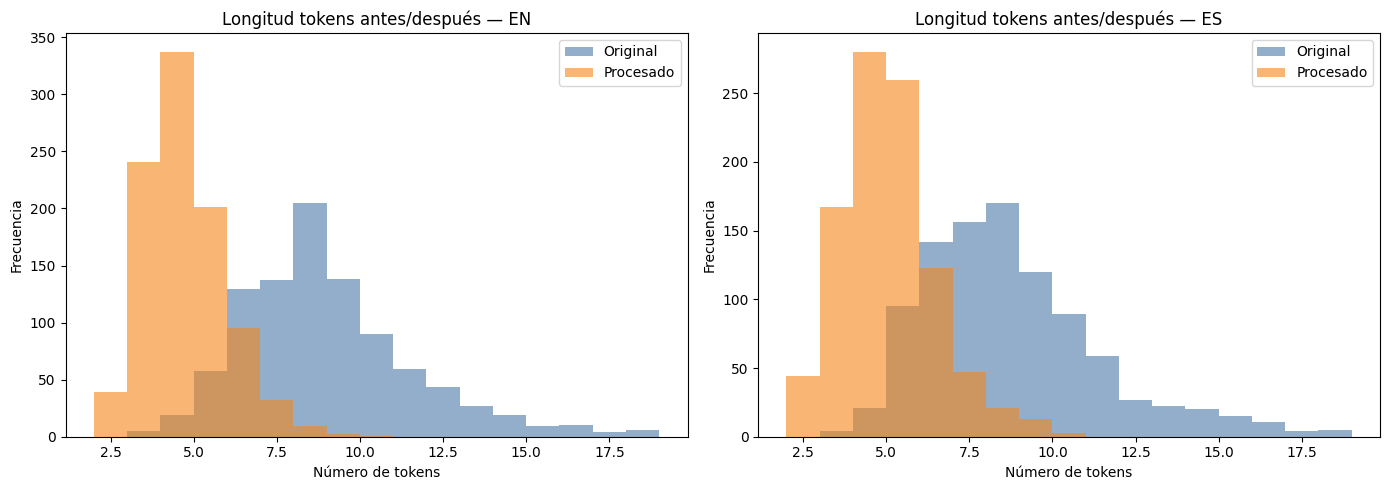

In [ ]:
# Reducción de longitud tras el preprocesamiento
for lang_label, train_df, test_df in [
    ('EN', data_train_en, data_test_en),
    ('ES', data_train_es, data_test_es)
]:
    train_df['n_orig']  = train_df['text'].str.split().str.len()
    train_df['n_clean'] = train_df['clean_text'].str.split().str.len()
    train_df['reduccion'] = (train_df['n_orig'] - train_df['n_clean']) / train_df['n_orig'] * 100

    print(f'\n[{lang_label}] Reducción de longitud tras preprocesamiento:')
    print(f'  Media tokens originales:  {train_df["n_orig"].mean():.2f}')
    print(f'  Media tokens procesados:  {train_df["n_clean"].mean():.2f}')
    print(f'  Reducción media:          {train_df["reduccion"].mean():.1f}%')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (lang_label, df) in zip(axes, [('EN', data_train_en), ('ES', data_train_es)]):
    ax.hist(df['n_orig'], bins=range(2, 20), alpha=0.6, label='Original', color='#4C78A8')
    ax.hist(df['n_clean'], bins=range(2, 20), alpha=0.6, label='Procesado', color='#F58518')
    ax.set_title(f'Longitud tokens antes/después - {lang_label}')
    ax.set_xlabel('Número de tokens')
    ax.set_ylabel('Frecuencia')
    ax.legend()

plt.tight_layout()
plt.show()

### 5.2 Vocabulario resultante

In [20]:
from collections import Counter

for lang_label, df in [('EN', data_train_en), ('ES', data_train_es)]:
    vocab_orig  = Counter(' '.join(df['text']).lower().split())
    vocab_clean = Counter(' '.join(df['clean_text']).lower().split())
    print(f'\n[{lang_label}]')
    print(f'  Vocabulario original:  {len(vocab_orig):,} tokens únicos')
    print(f'  Vocabulario procesado: {len(vocab_clean):,} tokens únicos')
    print(f'  Reducción: {(1 - len(vocab_clean)/len(vocab_orig))*100:.1f}%')
    print(f'  Top 15 tokens procesados: {[t for t, _ in vocab_clean.most_common(15)]}')


[EN]
  Vocabulario original:  855 tokens únicos
  Vocabulario procesado: 631 tokens únicos
  Reducción: 26.2%
  Top 15 tokens procesados: ['how', 'long', 'make', 'need', 'calorie', 'ingredient', 'chicken', 'cook', 'recipe', 'fridge', 'use', 'meal', 'good', 'dinner', 'milk']

[ES]
  Vocabulario original:  1,212 tokens únicos
  Vocabulario procesado: 691 tokens únicos
  Reducción: 43.0%
  Top 15 tokens procesados: ['ser', 'tiempo', 'cuanto', 'hacer', 'necesitar', 'caloria', 'ingrediente', 'pollo', 'nutricional', 'receta', 'estar', 'comida', 'deber', 'informacion', 'cocinar']


## 6. Exportación de datos limpios

In [ ]:
import os
os.makedirs('data', exist_ok=True)

data_train_es.to_csv('data/clean_data_train_es.csv', index=False)
data_test_es.to_csv('data/clean_data_test_es.csv', index=False)
data_train_en.to_csv('data/clean_data_train_en.csv', index=False)
data_test_en.to_csv('data/clean_data_test_en.csv', index=False)

print('Archivos exportados en data/:')
for fname in ['clean_data_train_es.csv', 'clean_data_test_es.csv',
              'clean_data_train_en.csv', 'clean_data_test_en.csv']:
    print(f'  data/{fname}')
print('\nContinuar en PoC_PLN.ipynb para la clasificación y análisis de resultados.')